# Portfolio Performance Analysis

**Docker image**: `ml4t`

This notebook demonstrates comprehensive portfolio performance analysis using
`ml4t-diagnostic` as a modern Plotly-based replacement for pyfolio. The strategy
under analysis is the highest-validation-Sharpe ETF allocation backtest as recorded in
`case_studies/etfs/run_log/registry.db` — resolved at runtime via
`resolve_best_backtest_runs(...)` so the metrics always reflect the current
best-Sharpe allocator on validation, not a baked-in hash. Daily portfolio
returns are loaded from the case study's run-log, so every metric below traces
to a real OOS strategy on real ETF data.

**Learning Objectives**:
- Compute summary statistics (Sharpe, Sortino, Calmar, max drawdown)
- Analyze rolling performance metrics over configurable windows
- Create drawdown analysis with recovery period tracking
- Compare strategy performance against benchmarks (alpha, beta, IR)
- Perform event analysis during market stress periods

**Book Reference**: Chapter 17, Section 17.3 (Portfolio Evaluation Metrics)

**Prerequisites**: The ETF case study (`case_studies/etfs/`) must have been run
to produce `run_log/backtest/<hash>/daily_returns.parquet`.

In [1]:
"""Portfolio Performance Analysis — compute risk-return metrics, drawdowns, and stress-period analysis for ETF portfolios."""

import warnings

warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl

# ml4t-diagnostic imports
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.evaluation.portfolio_analysis import (
    alpha_beta,
    annual_return,
    annual_volatility,
    calmar_ratio,
    conditional_var,
    information_ratio,
    max_drawdown,
    omega_ratio,
    stability_of_timeseries,
    value_at_risk,
)
from ml4t.diagnostic.metrics import sharpe_ratio, sortino_ratio
from ml4t.diagnostic.visualization import (
    combine_figures_to_html,
    create_portfolio_dashboard,
)

from case_studies.utils.registry.queries import resolve_best_backtest_runs
from data import load_etfs
from utils.paths import get_case_study_dir, get_output_dir
from utils.reproducibility import set_global_seeds

In [2]:
# Production defaults — Papermill overrides for CI testing.
# BACKTEST_HASH = None lets the notebook resolve the highest-validation-Sharpe allocation backtest
# from registry.db at runtime; pass a specific 12-char hash via Papermill to pin
# the strategy under analysis (useful for deterministic CI testing).
BACKTEST_HASH = None
BENCHMARK_SYMBOL = "SPY"
ETF_CASE_STUDY = "etfs"
ETF_LABEL = "fwd_ret_21d"
SEED = 42

In [3]:
set_global_seeds(SEED)

OUTPUT_DIR = get_output_dir(17, "portfolio_metrics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Strategy and Benchmark Returns

We load the daily portfolio return series from a registered ETF case-study
allocation backtest and use SPY as the benchmark. Rather than hard-code a
`prediction_hash` or `backtest_hash`, the notebook queries
`registry.db` via `resolve_best_backtest_runs()` and selects the allocation-stage
run with the highest validation Sharpe. The strategy is therefore whatever
the current case-study pipeline considers the best ETF allocator on real OOS
data; see `case_studies/etfs/run_log/backtest/<hash>/spec.json` for its full
specification.

In [4]:
# Resolve the backtest hash from the registry unless one was injected by Papermill
if BACKTEST_HASH is None:
    best_runs = resolve_best_backtest_runs(
        case_study=ETF_CASE_STUDY,
        label=ETF_LABEL,
        split="validation",
        stage="allocation",
        top_n=1,
    )
    if best_runs.is_empty():
        raise RuntimeError(
            f"No allocation-stage backtests found for {ETF_CASE_STUDY}/{ETF_LABEL} on "
            "validation. Run the ETF case study (Ch16/17 stages) before this notebook."
        )
    best_row = best_runs.row(0, named=True)
    BACKTEST_HASH = best_row["backtest_hash"]
    print(
        f"Resolved highest-validation-Sharpe allocation backtest: {BACKTEST_HASH} "
        f"(prediction={best_row['prediction_hash']}, Sharpe={best_row['sharpe']:.3f})"
    )
else:
    print(f"Using user-pinned BACKTEST_HASH={BACKTEST_HASH}")

Resolved highest-validation-Sharpe allocation backtest: 3b066a87f257 (prediction=a7b2d791305f, Sharpe=1.121)


In [5]:
# Load strategy daily returns from the registered backtest
backtest_dir = get_case_study_dir(ETF_CASE_STUDY) / "run_log" / "backtest" / BACKTEST_HASH
returns_path = backtest_dir / "daily_returns.parquet"
if not returns_path.exists():
    raise FileNotFoundError(
        f"Backtest daily returns not found at {returns_path}. Re-run the ETF case "
        "study (see case_studies/etfs/) before this notebook."
    )

strategy_df = (
    pl.read_parquet(returns_path)
    .rename({"daily_return": "strategy"})
    .with_columns(pl.col("timestamp").cast(pl.Date))
    .sort("timestamp")
)
# Trim the leading pre-trade window where daily_return == 0 (before the first rebalance)
first_active = strategy_df.filter(pl.col("strategy") != 0)["timestamp"].min()
strategy_df = strategy_df.filter(pl.col("timestamp") >= first_active)

strategy_returns = strategy_df.to_pandas().set_index("timestamp")["strategy"].astype(float)
strategy_returns.index = pd.to_datetime(strategy_returns.index)

In [6]:
# Load SPY benchmark over the same window
spy_lo, spy_hi = strategy_returns.index.min(), strategy_returns.index.max()
spy_data = (
    load_etfs()
    .filter(
        (pl.col("symbol") == BENCHMARK_SYMBOL)
        & (pl.col("timestamp") >= pl.lit(str(spy_lo.date())).str.to_datetime())
        & (pl.col("timestamp") <= pl.lit(str(spy_hi.date())).str.to_datetime())
    )
    .sort("timestamp")
)
spy_prices = spy_data.select(["timestamp", "close"]).to_pandas().set_index("timestamp")["close"]
spy_returns = spy_prices.pct_change().dropna()

# Align both series on the intersection of dates
common = strategy_returns.index.intersection(spy_returns.index)
strategy_returns = strategy_returns.loc[common].rename("Strategy")
spy_returns = spy_returns.loc[common]

print(
    f"Strategy: {len(strategy_returns):,} days  ({strategy_returns.index[0].date()} → {strategy_returns.index[-1].date()})"
)
print(f"Benchmark: {BENCHMARK_SYMBOL}, {len(spy_returns):,} days")

Strategy: 2,011 days  (2016-01-05 → 2023-12-29)
Benchmark: SPY, 2,011 days


## 2. PortfolioAnalysis Overview

The `PortfolioAnalysis` class provides a unified interface for portfolio analysis.

In [7]:
# Create analysis object
analysis = PortfolioAnalysis(
    returns=strategy_returns.values,
    benchmark=spy_returns.values,
    dates=strategy_returns.index,
    risk_free=0.0,  # Can specify annual risk-free rate
    periods_per_year=252,
)

print(f"  Returns: {len(strategy_returns)} observations")
print("  Benchmark: SPY")
print("  Risk-free rate: 0%")

  Returns: 2011 observations
  Benchmark: SPY
  Risk-free rate: 0%


## 3. Summary Statistics

The `compute_summary_stats()` method returns a `PortfolioMetrics` dataclass
with 22 performance metrics.

In [8]:
# Compute all metrics
metrics = analysis.compute_summary_stats()

# Display key metrics from the dataclass
print("\n" + "=" * 70)
print("PORTFOLIO PERFORMANCE SUMMARY")
print("=" * 70)
print("\nReturns")
print(f"  Total Return:        {metrics.total_return * 100:.2f}%")
print(f"  Annual Return:       {metrics.annual_return * 100:.2f}%")
print(f"  Annual Volatility:   {metrics.annual_volatility * 100:.2f}%")
print("\nRisk-Adjusted")
print(f"  Sharpe Ratio:        {metrics.sharpe_ratio:.3f}")
print(f"  Sortino Ratio:       {metrics.sortino_ratio:.3f}")
print(f"  Calmar Ratio:        {metrics.calmar_ratio:.3f}")
print(f"  Omega Ratio:         {metrics.omega_ratio:.3f}")
print("\nRisk")
print(f"  Max Drawdown:        {metrics.max_drawdown * 100:.2f}%")
print(f"  VaR (95%):           {metrics.var_95 * 100:.2f}%")
print(f"  CVaR (95%):          {metrics.cvar_95 * 100:.2f}%")
print("\nDistribution")
print(f"  Skewness:            {metrics.skewness:.3f}")
print(f"  Kurtosis:            {metrics.kurtosis:.3f}")
print(f"  Stability (R²):      {metrics.stability:.3f}")
print("\nWin/Loss")
print(f"  Win Rate:            {metrics.win_rate * 100:.2f}%")
print(f"  Profit Factor:       {metrics.profit_factor:.2f}")


PORTFOLIO PERFORMANCE SUMMARY

Returns
  Total Return:        194.42%
  Annual Return:       14.49%
  Annual Volatility:   12.79%

Risk-Adjusted
  Sharpe Ratio:        1.123
  Sortino Ratio:       1.028
  Calmar Ratio:        0.519
  Omega Ratio:         1.278

Risk
  Max Drawdown:        -27.94%
  VaR (95%):           -1.13%
  CVaR (95%):          -1.96%

Distribution
  Skewness:            -0.745
  Kurtosis:            19.974
  Stability (R²):      0.946

Win/Loss
  Win Rate:            57.78%
  Profit Factor:       1.28


In [9]:
# Access individual metrics programmatically
print("\nKey Metrics:")
print(f"  Total Return:      {metrics.total_return * 100:.2f}%")
print(f"  Annual Return:     {metrics.annual_return * 100:.2f}%")
print(f"  Annual Volatility: {metrics.annual_volatility * 100:.2f}%")
print(f"  Sharpe Ratio:      {metrics.sharpe_ratio:.3f}")
print(f"  Sortino Ratio:     {metrics.sortino_ratio:.3f}")
print(f"  Calmar Ratio:      {metrics.calmar_ratio:.3f}")
print(f"  Max Drawdown:      {metrics.max_drawdown * 100:.2f}%")

if metrics.alpha is not None:
    print("\nBenchmark-Relative:")
    print(f"  Alpha:             {metrics.alpha * 100:.2f}%")
    print(f"  Beta:              {metrics.beta:.3f}")
    print(f"  Information Ratio: {metrics.information_ratio:.3f}")


Key Metrics:
  Total Return:      194.42%
  Annual Return:     14.49%
  Annual Volatility: 12.79%
  Sharpe Ratio:      1.123
  Sortino Ratio:     1.028
  Calmar Ratio:      0.519
  Max Drawdown:      -27.94%

Benchmark-Relative:
  Alpha:             7.32%
  Beta:              0.494
  Information Ratio: 0.008


### 3.1 Metrics Explained

| Metric | Description | Good Range |
|--------|-------------|------------|
| **Sharpe Ratio** | Risk-adjusted return (excess return / volatility) | > 1.0 |
| **Sortino Ratio** | Return per unit downside risk | > 1.5 |
| **Calmar Ratio** | Annual return / max drawdown | > 0.5 |
| **Omega Ratio** | Probability-weighted gains vs losses | > 1.5 |
| **Tail Ratio** | Right tail (95%) / left tail (5%) | > 1.0 |
| **Alpha** | Excess return vs benchmark | > 0 |
| **Information Ratio** | Active return / tracking error | > 0.5 |
| **Up Capture** | Performance in up markets | > 100% |
| **Down Capture** | Performance in down markets | < 100% |

## 4. Rolling Metrics

Time-varying metrics reveal how strategy performance evolves.

In [10]:
# Compute rolling metrics
rolling = analysis.compute_rolling_metrics(
    windows=[21, 63, 252],  # 1-month, 3-month, 1-year
    metrics=["sharpe", "volatility", "returns"],
)

print("Rolling metrics computed:")
print(f"  windows: {rolling.windows}")
print(f"  sharpe: {list(rolling.sharpe.keys())}")
print(f"  volatility: {list(rolling.volatility.keys())}")
print(f"  returns: {list(rolling.returns.keys())}")

Rolling metrics computed:
  windows: [21, 63, 252]
  sharpe: [21, 63, 252]
  volatility: [21, 63, 252]
  returns: [21, 63, 252]


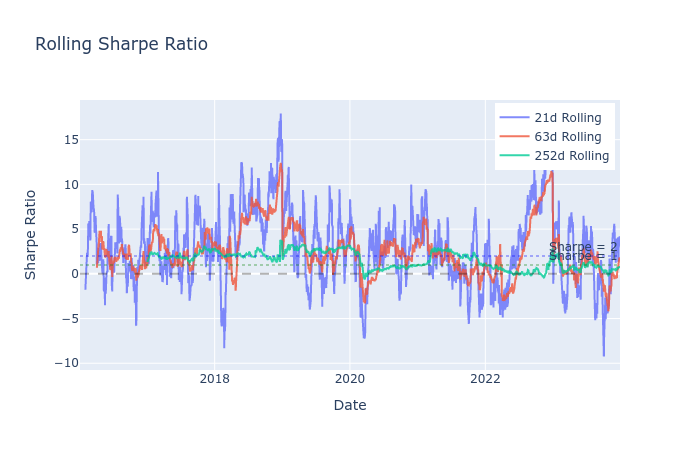

In [11]:
# Plot rolling Sharpe ratio
fig = go.Figure()

for window in [21, 63, 252]:
    if window in rolling.sharpe:
        sharpe_series = rolling.sharpe[window]
        fig.add_trace(
            go.Scatter(
                x=strategy_returns.index,
                y=sharpe_series.to_numpy(),
                name=f"{window}d Rolling",
                opacity=0.8,
            )
        )

fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.3)
fig.add_hline(y=1, line_dash="dot", line_color="green", opacity=0.3, annotation_text="Sharpe = 1")
fig.add_hline(y=2, line_dash="dot", line_color="blue", opacity=0.3, annotation_text="Sharpe = 2")

fig.update_layout(
    title="Rolling Sharpe Ratio",
    xaxis_title="Date",
    yaxis_title="Sharpe Ratio",
    height=450,
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99),
)
fig.show()

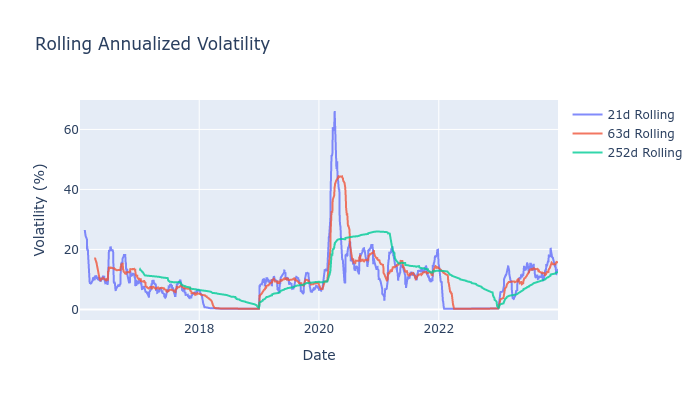

In [12]:
# Plot rolling volatility (annualized)
fig = go.Figure()

for window in [21, 63, 252]:
    if window in rolling.volatility:
        vol_series = rolling.volatility[window]
        fig.add_trace(
            go.Scatter(
                x=strategy_returns.index,
                y=vol_series.to_numpy() * 100,
                name=f"{window}d Rolling",
                opacity=0.8,
            )
        )

fig.update_layout(
    title="Rolling Annualized Volatility",
    xaxis_title="Date",
    yaxis_title="Volatility (%)",
    height=400,
)
fig.show()

## 5. Drawdown Analysis

Understanding drawdowns is critical for risk management.

In [13]:
# Compute drawdown analysis
drawdown = analysis.compute_drawdown_analysis(top_n=5)

print("\nTop 5 Drawdowns:")
if drawdown.top_drawdowns:
    for i, dd in enumerate(drawdown.top_drawdowns, 1):
        print(f"\n  #{i}: {dd.depth * 100:.2f}%")
        print(f"      Peak:     {dd.peak_date}")
        print(f"      Valley:   {dd.valley_date}")
        print(f"      Recovery: {dd.recovery_date or 'Not recovered'}")
        print(f"      Duration: {dd.duration_days or 'N/A'} days")


Top 5 Drawdowns:

  #1: -27.94%
      Peak:     2020-02-20 00:00:00
      Valley:   2020-03-20 00:00:00
      Recovery: 2020-08-04 00:00:00
      Duration: 21 days

  #2: -12.32%
      Peak:     2023-07-31 00:00:00
      Valley:   2023-10-27 00:00:00
      Recovery: Not recovered
      Duration: 63 days

  #3: -10.28%
      Peak:     2016-01-05 00:00:00
      Valley:   2016-01-20 00:00:00
      Recovery: 2016-03-02 00:00:00
      Duration: 10 days

  #4: -7.08%
      Peak:     2021-11-17 00:00:00
      Valley:   2021-12-01 00:00:00
      Recovery: 2023-01-12 00:00:00
      Duration: 9 days

  #5: -6.92%
      Peak:     2020-09-02 00:00:00
      Valley:   2020-09-23 00:00:00
      Recovery: 2020-10-09 00:00:00
      Duration: 14 days


Build a drawdown series when you want to combine underwater curves with custom
annotations or downstream report generation.

In [14]:
# Compute drawdown series
def compute_drawdown_series(returns: pd.Series) -> pd.Series:
    """Compute drawdown time series."""
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    return drawdown


dd_series = compute_drawdown_series(strategy_returns)
dd_benchmark = compute_drawdown_series(spy_returns)

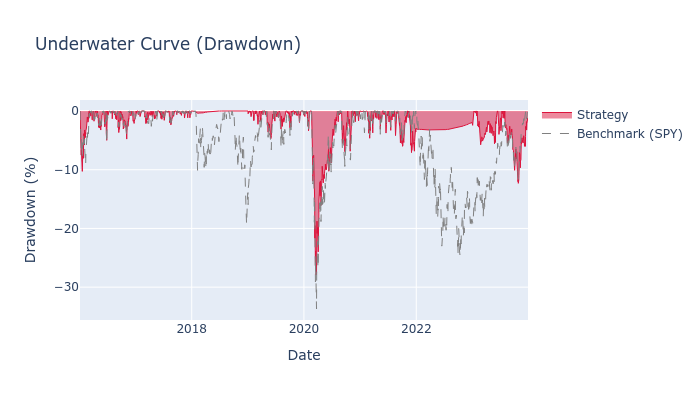

In [15]:
# Plot underwater curve
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=dd_series.index,
        y=dd_series * 100,
        name="Strategy",
        fill="tozeroy",
        line=dict(color="crimson", width=1),
    )
)

fig.add_trace(
    go.Scatter(
        x=dd_benchmark.index,
        y=dd_benchmark * 100,
        name="Benchmark (SPY)",
        line=dict(color="gray", width=1, dash="dash"),
    )
)

fig.update_layout(
    title="Underwater Curve (Drawdown)",
    xaxis_title="Date",
    yaxis_title="Drawdown (%)",
    height=400,
)
fig.show()

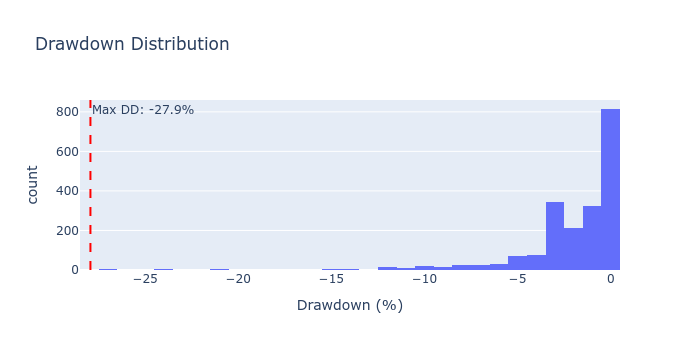

In [16]:
# Drawdown distribution
fig = px.histogram(
    dd_series * 100,
    nbins=50,
    title="Drawdown Distribution",
    labels={"value": "Drawdown (%)", "count": "Frequency"},
)
fig.add_vline(
    x=metrics.max_drawdown * 100,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Max DD: {metrics.max_drawdown * 100:.1f}%",
)
fig.update_layout(height=350, showlegend=False)
fig.show()

## 6. Monthly and Annual Returns

In [17]:
# Compute monthly returns
monthly = analysis.compute_monthly_returns()
monthly_df = monthly.to_pandas()  # Convert Polars to pandas

print("Monthly Return Statistics:")
print(f"  Mean:   {monthly_df['monthly_return'].mean() * 100:.2f}%")
print(f"  Std:    {monthly_df['monthly_return'].std() * 100:.2f}%")
print(f"  Best:   {monthly_df['monthly_return'].max() * 100:.2f}%")
print(f"  Worst:  {monthly_df['monthly_return'].min() * 100:.2f}%")

Monthly Return Statistics:
  Mean:   1.19%
  Std:    3.46%
  Best:   13.58%
  Worst:  -10.59%


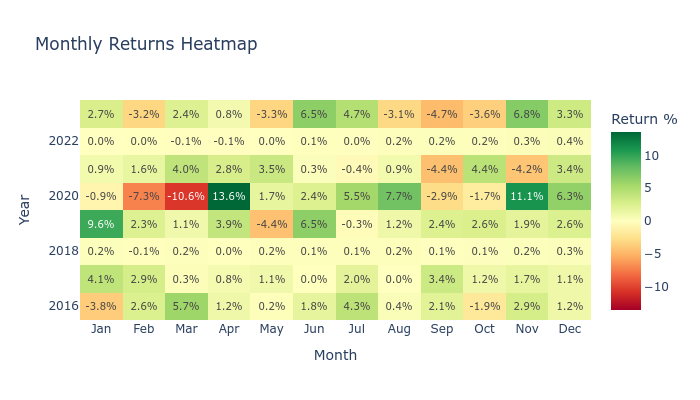

In [18]:
# Create monthly returns heatmap
# Reshape to year x month
monthly_df["year"] = monthly_df["year"].astype(int)
monthly_df["month"] = monthly_df["month"].astype(int)

heatmap_data = (
    monthly_df.pivot(index="year", columns="month", values="monthly_return") * 100
)  # Convert to percentage

# Month names
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig = go.Figure(
    data=go.Heatmap(
        z=heatmap_data.values,
        x=month_names,
        y=heatmap_data.index,
        colorscale="RdYlGn",
        zmid=0,
        text=np.round(heatmap_data.values, 1),
        texttemplate="%{text:.1f}%",
        textfont={"size": 10},
        colorbar=dict(title="Return %"),
    )
)

fig.update_layout(
    title="Monthly Returns Heatmap",
    xaxis_title="Month",
    yaxis_title="Year",
    height=400,
)
fig.show()

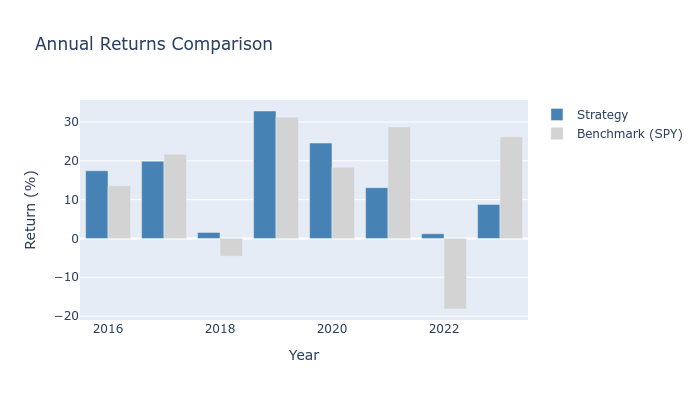

In [19]:
# Annual returns comparison
annual = analysis.compute_annual_returns()
annual_df = annual.to_pandas()  # Convert Polars to pandas

# Also compute benchmark annual
spy_annual = spy_returns.groupby(spy_returns.index.year).apply(lambda x: (1 + x).prod() - 1)

# Create comparison
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=annual_df["year"],
        y=annual_df["annual_return"] * 100,
        name="Strategy",
        marker_color="steelblue",
    )
)

fig.add_trace(
    go.Bar(
        x=spy_annual.index,
        y=spy_annual.values * 100,
        name="Benchmark (SPY)",
        marker_color="lightgray",
    )
)

fig.update_layout(
    title="Annual Returns Comparison",
    xaxis_title="Year",
    yaxis_title="Return (%)",
    barmode="group",
    height=400,
)
fig.show()

## 7. Benchmark-Relative Analysis

In [20]:
# Compute alpha and beta
alpha, beta = alpha_beta(strategy_returns.values, spy_returns.values, periods_per_year=252)

print(f"Alpha: {alpha * 100:.2f}% (annualized)")
print(f"Beta:  {beta:.3f}")

# Interpretation
if beta < 0.8:
    beta_interp = "Defensive (low market exposure)"
elif beta > 1.2:
    beta_interp = "Aggressive (high market exposure)"
else:
    beta_interp = "Neutral (market-like exposure)"
print(f"       {beta_interp}")

Alpha: 7.32% (annualized)
Beta:  0.494
       Defensive (low market exposure)


In [21]:
# Tracking error and information ratio
active_returns = strategy_returns.values - spy_returns.values
tracking_error = active_returns.std(ddof=1) * np.sqrt(252)
ir = information_ratio(strategy_returns.values, spy_returns.values, periods_per_year=252)

print(f"\nTracking Error:   {tracking_error * 100:.2f}% (annualized)")
print(f"Information Ratio: {ir:.3f}")
if ir > 0.5:
    print("  Strong active return")
elif ir > 0.25:
    print("  Positive but modest active return")
elif ir > 0:
    print("  Economically negligible active return after tracking error")
else:
    print("  Underperforming the benchmark")


Tracking Error:   12.95% (annualized)
Information Ratio: 0.008
  Economically negligible active return after tracking error


In [22]:
# Up/Down Capture Ratios
# Standard approach: mean monthly returns in up/down benchmark months
strat_monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
bench_monthly = spy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)

up_months = bench_monthly > 0
down_months = bench_monthly < 0

up_capture = strat_monthly[up_months].mean() / bench_monthly[up_months].mean()
down_capture = strat_monthly[down_months].mean() / bench_monthly[down_months].mean()

print("\nCapture Ratios (monthly):")
print(f"  Up Capture:   {up_capture * 100:.1f}%")
print(f"  Down Capture: {down_capture * 100:.1f}%")

# Ideal: High up capture, low down capture
capture_spread = up_capture - down_capture
print(f"\n  Capture Spread: {capture_spread * 100:.1f}pp")
if capture_spread > 0.2:
    print("  Capture profile: asymmetric — captures >20pp more upside than downside")
elif capture_spread > 0:
    print("  Capture profile: asymmetric — captures more upside than downside")
elif capture_spread < 0:
    print("  Capture profile: asymmetric — captures more downside than upside")
else:
    print("  Capture profile: symmetric (up capture == down capture)")


Capture Ratios (monthly):
  Up Capture:   70.2%
  Down Capture: 40.9%

  Capture Spread: 29.3pp
  Capture profile: asymmetric — captures >20pp more upside than downside


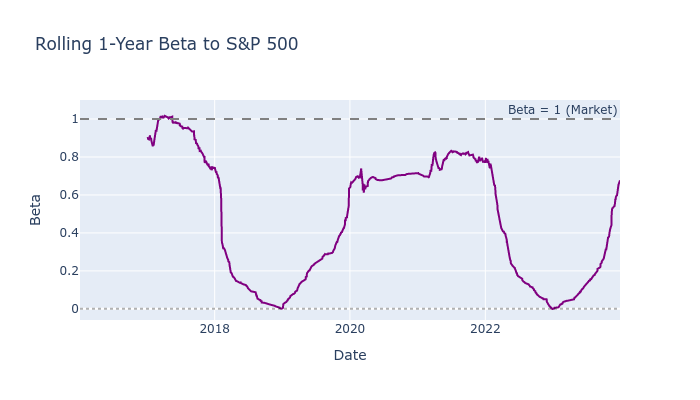

In [23]:
# Rolling Beta
rolling_beta = pd.Series(index=strategy_returns.index, dtype=float)

window = 252
for i in range(window, len(strategy_returns)):
    strat_window = strategy_returns.iloc[i - window : i].values
    bench_window = spy_returns.iloc[i - window : i].values
    _, beta_i = alpha_beta(strat_window, bench_window)
    rolling_beta.iloc[i] = beta_i

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=rolling_beta.index,
        y=rolling_beta,
        name="Rolling 1Y Beta",
        line=dict(color="purple", width=2),
    )
)

fig.add_hline(y=1, line_dash="dash", line_color="gray", annotation_text="Beta = 1 (Market)")
fig.add_hline(y=0, line_dash="dot", line_color="black", opacity=0.3)

fig.update_layout(
    title="Rolling 1-Year Beta to S&P 500",
    xaxis_title="Date",
    yaxis_title="Beta",
    height=400,
)
fig.show()

## 8. Risk Metrics (VaR, CVaR)

In [24]:
# Value at Risk
var_95 = value_at_risk(strategy_returns.values, confidence=0.95)
var_99 = value_at_risk(strategy_returns.values, confidence=0.99)

print("Value at Risk (VaR):")
print(f"  95% VaR: {var_95 * 100:.2f}% (daily)")
print(f"  99% VaR: {var_99 * 100:.2f}% (daily)")
print(f"\n  Interpretation: On 95% of days, losses won't exceed {abs(var_95) * 100:.2f}%")

Value at Risk (VaR):
  95% VaR: -1.13% (daily)
  99% VaR: -2.23% (daily)

  Interpretation: On 95% of days, losses won't exceed 1.13%


In [25]:
# Conditional VaR (Expected Shortfall)
cvar_95 = conditional_var(strategy_returns.values, confidence=0.95)
cvar_99 = conditional_var(strategy_returns.values, confidence=0.99)

print("Conditional VaR (Expected Shortfall):")
print(f"  95% CVaR: {cvar_95 * 100:.2f}% (daily)")
print(f"  99% CVaR: {cvar_99 * 100:.2f}% (daily)")
print(f"\n  Interpretation: When losses exceed VaR, average loss is {abs(cvar_95) * 100:.2f}%")

Conditional VaR (Expected Shortfall):
  95% CVaR: -1.96% (daily)
  99% CVaR: -3.71% (daily)

  Interpretation: When losses exceed VaR, average loss is 1.96%


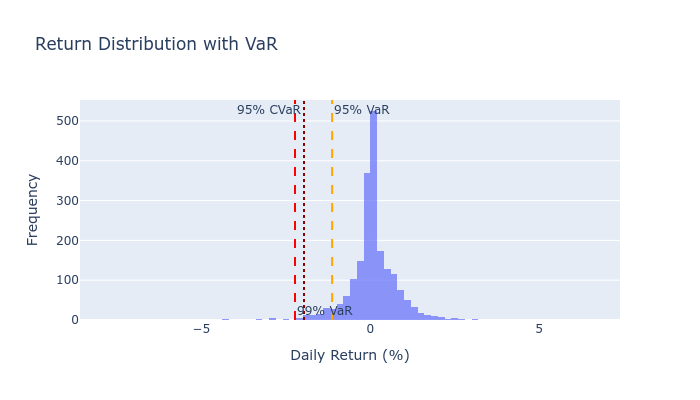

In [26]:
# Visualize return distribution with VaR
fig = go.Figure()

# Histogram of returns
fig.add_trace(go.Histogram(x=strategy_returns * 100, nbinsx=100, name="Daily Returns", opacity=0.7))

# VaR lines — stagger annotation y-positions to prevent overlap at the top
fig.add_vline(
    x=var_95 * 100,
    line_dash="dash",
    line_color="orange",
    annotation_text="95% VaR",
    annotation_position="top right",
)
fig.add_vline(
    x=var_99 * 100,
    line_dash="dash",
    line_color="red",
    annotation_text="99% VaR",
    annotation_position="bottom right",
)
fig.add_vline(
    x=cvar_95 * 100,
    line_dash="dot",
    line_color="darkred",
    annotation_text="95% CVaR",
    annotation_position="top left",
)

fig.update_layout(
    title="Return Distribution with VaR",
    xaxis_title="Daily Return (%)",
    yaxis_title="Frequency",
    height=400,
    showlegend=False,
)
fig.show()

## 9. Event Analysis

Analyze performance during specific market events or stress periods.

In [27]:
# Define market stress periods
STRESS_PERIODS = {
    "COVID Crash (2020)": ("2020-02-19", "2020-03-23"),
    "COVID Recovery": ("2020-03-23", "2020-08-31"),
    "2022 Bear Market": ("2022-01-03", "2022-10-12"),
    "2023 Banking Crisis": ("2023-03-01", "2023-03-31"),
    "2023 Rally": ("2023-10-27", "2023-12-29"),
}


def analyze_period(returns: pd.Series, benchmark: pd.Series, start: str, end: str):
    """Analyze returns over a specific period."""
    period_ret = returns.loc[start:end]
    period_bench = benchmark.loc[start:end]

    if len(period_ret) == 0:
        return None

    cum_ret = (1 + period_ret).prod() - 1
    cum_bench = (1 + period_bench).prod() - 1
    excess = cum_ret - cum_bench

    return {
        "strategy_return": cum_ret,
        "benchmark_return": cum_bench,
        "excess_return": excess,
        "days": len(period_ret),
    }

In [28]:
# Analyze each period
print("\n" + "=" * 70)
print("STRESS PERIOD ANALYSIS")
print("=" * 70)

period_results = []
for name, (start, end) in STRESS_PERIODS.items():
    result = analyze_period(strategy_returns, spy_returns, start, end)
    if result:
        result["period"] = name
        period_results.append(result)
        print(f"\n{name}:")
        print(f"  Strategy:  {result['strategy_return'] * 100:+.2f}%")
        print(f"  Benchmark: {result['benchmark_return'] * 100:+.2f}%")
        print(f"  Excess:    {result['excess_return'] * 100:+.2f}%")


STRESS PERIOD ANALYSIS

COVID Crash (2020):
  Strategy:  -27.07%
  Benchmark: -33.40%
  Excess:    +6.33%

COVID Recovery:
  Strategy:  +46.86%
  Benchmark: +53.34%
  Excess:    -6.48%

2022 Bear Market:
  Strategy:  +0.42%
  Benchmark: -24.06%
  Excess:    +24.48%

2023 Banking Crisis:
  Strategy:  +2.37%
  Benchmark: +3.71%
  Excess:    -1.34%

2023 Rally:
  Strategy:  +11.31%
  Benchmark: +15.68%
  Excess:    -4.37%


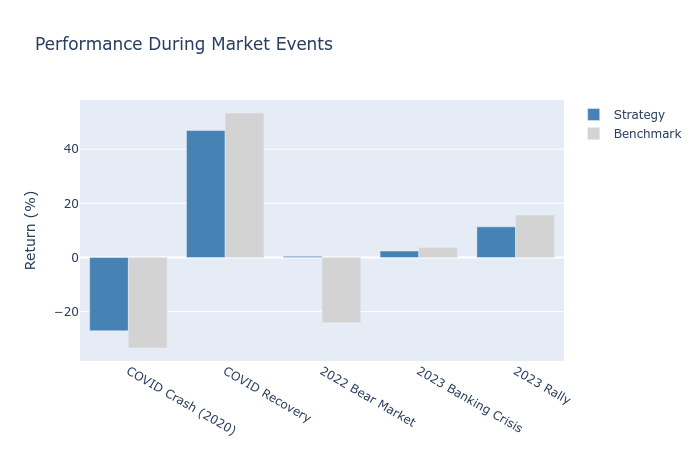

In [29]:
# Visualize stress period performance
if period_results:
    period_df = pd.DataFrame(period_results)

    fig = go.Figure()

    fig.add_trace(
        go.Bar(
            x=period_df["period"],
            y=period_df["strategy_return"] * 100,
            name="Strategy",
            marker_color="steelblue",
        )
    )

    fig.add_trace(
        go.Bar(
            x=period_df["period"],
            y=period_df["benchmark_return"] * 100,
            name="Benchmark",
            marker_color="lightgray",
        )
    )

    fig.update_layout(
        title="Performance During Market Events",
        yaxis_title="Return (%)",
        barmode="group",
        height=450,
    )
    fig.show()

## 10. Stability Analysis

In [30]:
# Stability of returns (R² of cumulative returns vs time)
stability = stability_of_timeseries(strategy_returns.values)
print(f"Stability (R²): {stability:.3f}")

if stability > 0.9:
    print("  Highly stable returns (consistent performance)")
elif stability > 0.7:
    print("  Moderately stable returns")
else:
    print("  Unstable returns (high variance in performance)")

Stability (R²): 0.946
  Highly stable returns (consistent performance)


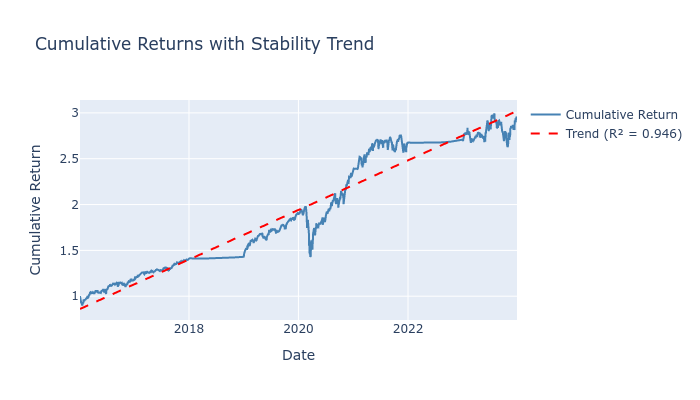

In [31]:
# Cumulative returns with trend line
cumulative = (1 + strategy_returns).cumprod()

# Fit trend line
x = np.arange(len(cumulative))
coeffs = np.polyfit(x, cumulative, 1)
trend = np.polyval(coeffs, x)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=cumulative.index,
        y=cumulative,
        name="Cumulative Return",
        line=dict(color="steelblue", width=2),
    )
)

fig.add_trace(
    go.Scatter(
        x=cumulative.index,
        y=trend,
        name=f"Trend (R² = {stability:.3f})",
        line=dict(color="red", dash="dash"),
    )
)

fig.update_layout(
    title="Cumulative Returns with Stability Trend",
    xaxis_title="Date",
    yaxis_title="Cumulative Return",
    height=400,
)
fig.show()

## 11. Full Performance Report

In [32]:
# Create comprehensive summary table
summary_data = {"Category": [], "Metric": [], "Value": []}


def add_metric(category: str, name: str, value: str) -> None:
    summary_data["Category"].append(category)
    summary_data["Metric"].append(name)
    summary_data["Value"].append(value)

In [33]:
returns_metrics = [
    ("Total Return", f"{metrics.total_return * 100:.2f}%"),
    ("Annual Return (CAGR)", f"{metrics.annual_return * 100:.2f}%"),
    ("Best Month", f"{monthly_df['monthly_return'].max() * 100:.2f}%"),
    ("Worst Month", f"{monthly_df['monthly_return'].min() * 100:.2f}%"),
]
risk_metrics = [
    ("Annual Volatility", f"{metrics.annual_volatility * 100:.2f}%"),
    ("Max Drawdown", f"{metrics.max_drawdown * 100:.2f}%"),
    ("95% VaR (Daily)", f"{var_95 * 100:.2f}%"),
    ("95% CVaR (Daily)", f"{cvar_95 * 100:.2f}%"),
]
risk_adjusted_metrics = [
    ("Sharpe Ratio", f"{metrics.sharpe_ratio:.3f}"),
    ("Sortino Ratio", f"{metrics.sortino_ratio:.3f}"),
    ("Calmar Ratio", f"{metrics.calmar_ratio:.3f}"),
    ("Omega Ratio", f"{metrics.omega_ratio:.3f}"),
]
benchmark_metrics = []
if metrics.alpha is not None:
    benchmark_metrics = [
        ("Alpha", f"{metrics.alpha * 100:.2f}%"),
        ("Beta", f"{metrics.beta:.3f}"),
        ("Tracking Error", f"{tracking_error * 100:.2f}%"),
        ("Information Ratio", f"{metrics.information_ratio:.3f}"),
        ("Up Capture", f"{up_capture * 100:.1f}%"),
        ("Down Capture", f"{down_capture * 100:.1f}%"),
    ]
other_metrics = [
    ("Stability (R²)", f"{stability:.3f}"),
    ("Win Rate", f"{metrics.win_rate * 100:.1f}%"),
    ("Profit Factor", f"{metrics.profit_factor:.2f}"),
]

In [34]:
for name, value in returns_metrics:
    add_metric("Returns", name, value)
for name, value in risk_metrics:
    add_metric("Risk", name, value)
for name, value in risk_adjusted_metrics:
    add_metric("Risk-Adjusted", name, value)
for name, value in benchmark_metrics:
    add_metric("Benchmark", name, value)
for name, value in other_metrics:
    add_metric("Other", name, value)

In [35]:
summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 70)
print("COMPREHENSIVE PERFORMANCE REPORT")
print("=" * 70)
summary_df


COMPREHENSIVE PERFORMANCE REPORT


,Category,Metric,Value
0,Returns,Total Return,194.42%
1,Returns,Annual Return (CAGR),14.49%
2,Returns,Best Month,13.58%
3,Returns,Worst Month,-10.59%
4,Risk,Annual Volatility,12.79%
5,Risk,Max Drawdown,-27.94%
6,Risk,95% VaR (Daily),-1.13%
7,Risk,95% CVaR (Daily),-1.96%
8,Risk-Adjusted,Sharpe Ratio,1.123
9,Risk-Adjusted,Sortino Ratio,1.028


**Interpretation**: The comprehensive report shows the strategy from four angles — absolute
returns, risk, risk-adjusted performance, and benchmark-relative attribution. Positive
absolute alpha (7.32%) and defensive beta (0.494) with an IR ≈ 0.008 indicates little
differentiated active return after accounting for tracking error (12.95%). The up/down
capture asymmetry (if visible) reveals whether the residual return profile comes from
upside participation or downside avoidance — the latter is more robust.

## 12. Standalone Metric Functions

Individual metric functions are useful for quick checks in other notebooks.

In [36]:
# Example: Computing metrics without PortfolioAnalysis class
returns_arr = strategy_returns.values
benchmark_arr = spy_returns.values

print("Standalone Metric Functions:")
print(f"  sharpe_ratio():       {sharpe_ratio(returns_arr):.3f}")
print(f"  sortino_ratio():      {sortino_ratio(returns_arr):.3f}")
print(f"  calmar_ratio():       {calmar_ratio(returns_arr):.3f}")
print(f"  omega_ratio():        {omega_ratio(returns_arr):.3f}")
print(f"  max_drawdown():       {max_drawdown(returns_arr) * 100:.2f}%")
print(f"  annual_return():      {annual_return(returns_arr) * 100:.2f}%")
print(f"  annual_volatility():  {annual_volatility(returns_arr) * 100:.2f}%")

Standalone Metric Functions:
  sharpe_ratio():       1.123
  sortino_ratio():      1.028
  calmar_ratio():       0.519
  omega_ratio():        1.278
  max_drawdown():       -27.94%
  annual_return():      14.49%
  annual_volatility():  12.79%


## 13. Portfolio Dashboard (Pyfolio Replacement)

The library provides `create_portfolio_dashboard()` which generates a complete
tear sheet in a single call. This is the production replacement for pyfolio's
`create_full_tear_sheet()`.

In [37]:
# Create comprehensive tear sheet
# This generates all standard portfolio visualizations automatically
tear_sheet = create_portfolio_dashboard(
    analysis,
    theme="default",
    include_benchmark=True,
    height_per_row=350,
)

print("PortfolioTearSheet generated!")
print(f"  Figures included: {list(tear_sheet.figures.keys())}")

PortfolioTearSheet generated!
  Figures included: ['Cumulative Returns', 'Drawdown', 'Rolling Sharpe Ratio', 'Rolling Volatility', 'Rolling Beta', 'Annual Returns', 'Monthly Returns Heatmap', 'Returns Distribution', 'Top Drawdowns']


### 13.1 Viewing the Tear Sheet

The `show()` method displays metrics and all figures in sequence.

In [38]:
# Display key metrics from the tear sheet (same as computed above)
ts = tear_sheet.metrics
print(
    f"Sharpe: {ts.sharpe_ratio:.3f}  |  Sortino: {ts.sortino_ratio:.3f}  |  Calmar: {ts.calmar_ratio:.3f}"
)
print(f"Annual Return: {ts.annual_return * 100:.2f}%  |  Max DD: {ts.max_drawdown * 100:.2f}%")
print(f"Alpha: {ts.alpha * 100:.2f}%  |  Beta: {ts.beta:.3f}  |  IR: {ts.information_ratio:.3f}")

Sharpe: 1.123  |  Sortino: 1.028  |  Calmar: 0.519
Annual Return: 14.49%  |  Max DD: -27.94%
Alpha: 7.32%  |  Beta: 0.494  |  IR: 0.008


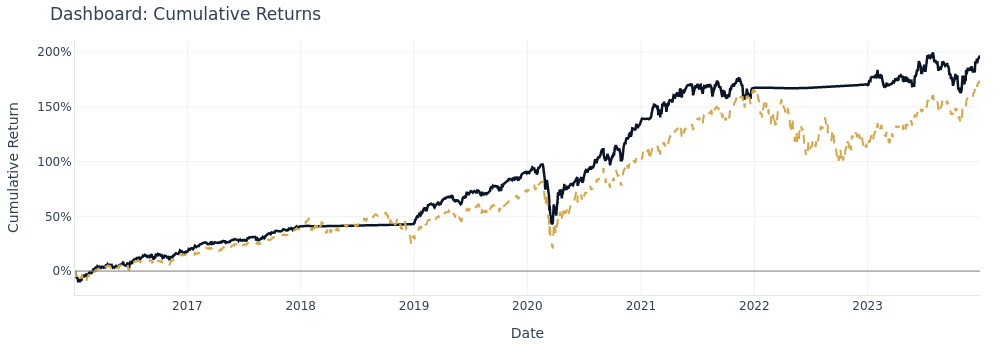

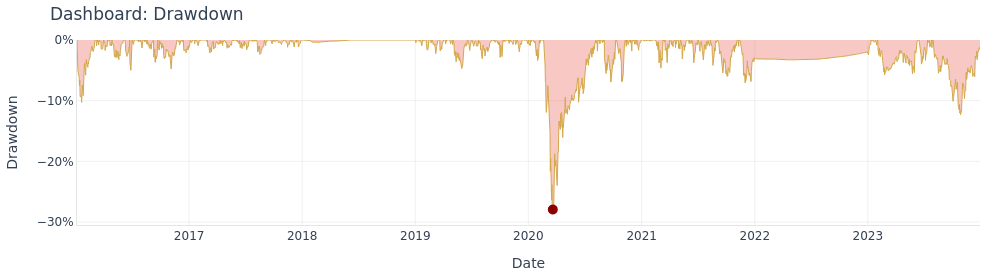

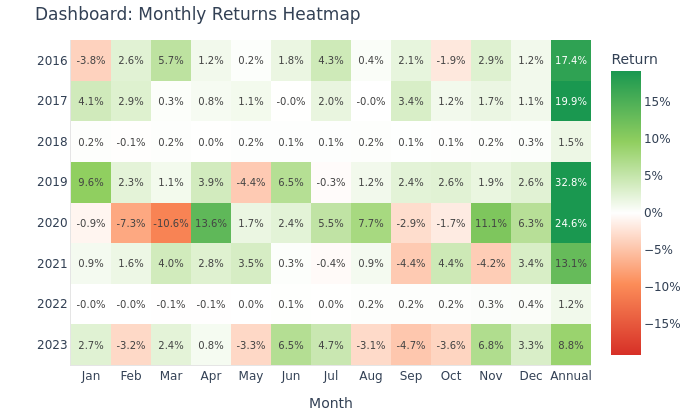

In [39]:
# Access individual figures from the tear sheet
# (For more control than show(), display specific figures)
for name in ["Cumulative Returns", "Drawdown", "Monthly Returns Heatmap"]:
    if name in tear_sheet.figures:
        fig = tear_sheet.figures[name]
        fig.update_layout(title=f"Dashboard: {name}")
        fig.show()

### 13.2 Exporting to HTML

The tear sheet can be saved as a self-contained HTML file for sharing.

In [40]:
# Export to HTML (self-contained, shareable file)
html_path = OUTPUT_DIR / "portfolio_dashboard.html"
tear_sheet.save_html(html_path, include_plotlyjs="cdn")
print(f"Dashboard saved to: {html_path}")

Dashboard saved to: 17_portfolio_construction/output/portfolio_metrics/portfolio_dashboard.html


## 14. Report Generation

For combining multiple figures with narrative text, use `combine_figures_to_html()`.
This is useful when you want to create a custom report with specific figures and
explanatory sections.

In [41]:
# Collect figures we created earlier for a custom report
custom_figures = []
custom_sections = []

The first custom section focuses on cumulative growth against the benchmark.

In [42]:
# Add cumulative returns figure
fig_cum = go.Figure()
fig_cum.add_trace(
    go.Scatter(
        x=strategy_returns.index,
        y=(1 + strategy_returns).cumprod(),
        name="Strategy",
        line=dict(color="steelblue", width=2),
    )
)
fig_cum.add_trace(
    go.Scatter(
        x=spy_returns.index,
        y=(1 + spy_returns).cumprod(),
        name="Benchmark (SPY)",
        line=dict(color="gray", width=1, dash="dash"),
    )
)
fig_cum.update_layout(
    title="Cumulative Returns",
    xaxis_title="Date",
    yaxis_title="Cumulative Return",
    height=400,
)
custom_figures.append(fig_cum)
custom_sections.append(
    {
        "title": "Strategy Performance",
        "text": f"The strategy achieved a total return of {metrics.total_return * 100:.1f}% "
        f"vs benchmark return of {((1 + spy_returns).prod() - 1) * 100:.1f}%. "
        f"Sharpe ratio: {metrics.sharpe_ratio:.2f}.",
        "figure_index": 0,
    }
)

The second section summarizes drawdown severity and recovery behavior.

In [43]:
# Add drawdown figure
fig_dd = go.Figure()
fig_dd.add_trace(
    go.Scatter(
        x=dd_series.index,
        y=dd_series * 100,
        fill="tozeroy",
        line=dict(color="crimson", width=1),
        name="Drawdown",
    )
)
fig_dd.update_layout(
    title="Drawdown",
    xaxis_title="Date",
    yaxis_title="Drawdown (%)",
    height=350,
)
custom_figures.append(fig_dd)
custom_sections.append(
    {
        "title": "Risk Analysis",
        "text": f"Maximum drawdown reached {metrics.max_drawdown * 100:.1f}%. "
        f"The strategy has a Calmar ratio of {metrics.calmar_ratio:.2f}.",
        "figure_index": 1,
    }
)

Export the assembled figures and narrative as a standalone HTML report.

In [44]:
# Generate the custom report
report_path = OUTPUT_DIR / "custom_strategy_report.html"
combine_figures_to_html(
    figures=custom_figures,
    title="Strategy Performance Report",
    sections=custom_sections,
    output_file=report_path,
    theme="default",
    include_toc=True,
)
print(f"Custom report saved to: {report_path}")

Custom report saved to: 17_portfolio_construction/output/portfolio_metrics/custom_strategy_report.html


## Key Takeaways

1. **Multi-dimensional evaluation is non-negotiable.** Sharpe ratio alone misses
   drawdown profiles, tail risk (VaR/CVaR), and benchmark-relative attribution.
   Always report at least Sharpe, max drawdown, and Sortino together.
2. **Rolling metrics expose regime dependence.** Aggregate Sharpe can be positive
   while rolling windows show extended negative periods — a critical warning for
   investors with finite horizons.
3. **Benchmark comparison separates alpha from beta.** The ETF allocator above posts
   Sharpe ≈ 1.12 with beta 0.494 and alpha 7.32% but IR 0.008 — defensive market
   exposure with little differentiated active return once tracking error is priced in.
   Up/down capture ratios reveal asymmetric exposure that aggregate alpha misses.
4. **Stress-period analysis tests robustness.** A max drawdown of −27.94% on this
   strategy is the kind of timing and recovery question that matters more to real
   investors than aggregate statistics suggest.

**Next**: These metrics are used throughout Ch17-19 to evaluate allocation methods,
transaction cost impact, and risk controls.

**Book**: Section 17.3 discusses the full evaluation framework.